In [1]:
#make sure to set the scenario in drivers.py to your selected scenario (SSP2) is the only option right now. 
# set the scenario to the correct ones in the other pre-processing files as well (lifetime, materials, capacity) to ensure that the correct data is used for the model.

from pathlib import Path
import prism
import pandas as pd
import numpy as np
import xarray as xr
import scipy
import matplotlib.pyplot as plt
import warnings
import prism
import logging
import pickle

from imagematerials.model import GenericStocks, MaterialIntensities, GenericMaterials, SharesInflowStocks
from imagematerials.factory import ModelFactory, Sector
from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.fossil_fuels.preprocessing.ffconstants import (path_base,STANDARD_SCEN_EXTERNAL_DATA)
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_extraction
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_processing
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_transport
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_pipelines
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_storage
from imagematerials.fossil_fuels.preprocessing.ffconstants import REGIONS_TIMER

from imagematerials.util import reindex_material

In [2]:
YEAR_START = 1971   # start year of the simulation period
YEAR_END = 2100     # end year of the calculations
YEAR_OUT = 2100     # year of output generation = last year of reporting
year_end = 2100     # end year of the calculations
year_out = 2100
year_start = 1971 

#define path base or current path?
#Select scenario here and also in "ffconstants.py" as well 
circular_economy_config = None
climate_policy_config = "SSP2_baseline" 
scenario = "SSP2_baseline" 
base_dir =  Path(path_base,"data", "raw")


In [13]:

scenario_list = {"SSP2":("SSP2_baseline", None), 
                #  "SSP1_climate_policy":("SSP1_climate_policy", None), 
                #  "SSP1_delayed_action":("SSP1_delayed_action", None), 
                #  "SSP2_climate_policy":("SSP2_climate_policy", None), 
                #  "SSP2_delayed_action":("SSP2_delayed_action", None), 
                #  "SSP2_climate_policy_resource_efficiency":("SSP2_climate_policy_resource_efficiency", None),
                #  "SSP3_no_policy":("SSP3_no_policy", None)
                # add your scenarios
                 }

time_start = 1971
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1)

materials = [
    'aluminium', 'brick',  'cobalt', 'concrete','cement', 'copper', 'glass',        
    'lead', 'lithium', 'manganese', 'neodymium', 'nickel', 'plastics',
    'rubber', 'sand', 'steel', 'tantalum', 'titanium', 'wood'
]



# Run model

In [4]:

all_output = {}

# add debugging statements
logging.basicConfig(
    level=logging.DEBUG,
    format='%(name)s - %(levelname)s - %(message)s',
    force=True  # Override any existing config
)

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path(base_dir, "image", climate_scen)
    circular_economy_scenario_dir = None 
    scenario = base_dir /"fossil_fuels"/ STANDARD_SCEN_EXTERNAL_DATA

    # get preprocessing data

    # FOSSIL FUELS
    ff_sector = get_preprocessing_data("fossil_fuels", base_dir,
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dir, cache = False) 
    ff_extr, ff_proc, ff_trp, ff_pipe, ff_str = (       
    {sec.name: sec for sec in ff_sector}[k]
    for k in ["ff_extr", "ff_proc", "ff_trp", "ff_pipe", "ff_str"])
    
    # #ELECTRICITY
    elc_sector = get_preprocessing_data("electricity", base_dir, climate_policy_scenario_dir, circular_economy_scenario_dir, cache = False)
    elc_gen, elc_grid_lines, elc_grid_add, elc_stor_phs, elc_stor_other = (
    {sec.name: sec for sec in elc_sector}[k]
    for k in ["elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"])
    
     # Reindex materials in all sectors to ensure consistency
    for sec in [
    ff_extr, 
    ff_proc,
    ff_trp,
    ff_pipe,
    ff_str,
    elc_gen,
    elc_grid_lines,
    elc_grid_add,
    elc_stor_phs,
    elc_stor_other,
    ]:
        for key, val in sec.prep_data.items():
            sec.prep_data[key] = reindex_material(val, materials)    

    factory = ModelFactory(
   [ *ff_sector, *elc_sector], complete_timeline
    ).add(GenericStocks, ["ff_extr","ff_proc","ff_trp","ff_pipe", "ff_str",
                         "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                          ]
    ).add(SharesInflowStocks, ["elc_stor_other"]
    ).add(MaterialIntensities, ["ff_extr","ff_proc","ff_trp","ff_pipe", "ff_str", 
                         "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                          ])
    # ).add(GenericMaterials, ["ff_trp"])
    model = factory.finish()

    model.simulate(simulation_timeline)
    # save relevant outputs only to reduce memory usage
    all_output[scen_id] = model
    
    print(f"Finished {scen_id}")

Finished SSP2


In [5]:
list(model.ff_extr)

['lifetimes',
 'stocks',
 'material_intensities',
 'knowledge_graph',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials']

In [7]:
model.ff_extr["stock_by_cohort_materials"]
model.ff_str["stock_by_cohort_materials"]

Magnitude,[[[[150492518.19793358 0.0 10924076.194063198 2899845680.6058674]] [[1526348879.7585466 0.0 110795883.14998586 29411270799.814434]] [[47306223.054985784 0.0 3433903.500945668 911545292.9783047]] ... [[64673166.844319865 0.0 4694549.674486163 1246189549.9545088]] [[16351421.048856271 0.0 1186930.5634448968 315076113.2053727]] [[9667308.939204527 0.0 701738.6691909885 186279719.4579715]]] [[[152947426.00564542 0.0 11102275.085688982 2947149386.382894]] [[1550525786.1563983 0.0 112550856.55856091 29877136468.272533]] [[50301838.97624448 0.0 3651351.7632502336 969267922.608244]] ... [[65712960.107593834 0.0 4770027.053495389 1266225363.2915037]] [[16679337.676491182 0.0 1210733.6485980907 321394750.3551296]] [[9766923.723005168 0.0 708969.5900455528 188199200.26663768]]] [[[155511179.04539615 0.0 11288374.925630279 2996550434.803674]] [[1582599713.9447331 0.0 114879065.5299984 30495170122.50867]] [[53489176.80879267 0.0 3882716.895257539 1030684848.5592742]] ... [[66945902.83852135 0.0 4859524.926857133 1289982980.5838938]] [[17026826.830460764 0.0 1235957.4805867458 328090531.21029985]] [[9814346.41922112 0.0 712411.9481972691 189112989.88509324]]] ... [[[60646259.809566006 0.0 4402241.194298446 1168594935.2137694]] [[658011337.1885647 0.0 47764274.72993133 12679243837.399958]] [[169777684.74764225 0.0 12323963.918229869 3271452240.1119285]] ... [[55675171.847609274 0.0 4041395.7229482867 1072806864.6371818]] [[622468724.4810953 0.0 45184277.96994753 11994371970.204256]] [[431918026.82836866 0.0 31352425.297693767 8322643806.296892]]] [[[60718769.018480405 0.0 4407504.553118122 1169992117.7368107]] [[654286921.5912555 0.0 47493923.75002514 12607477940.915768]] [[167971817.18210375 0.0 12192878.10002073 3236654913.823685]] ... [[55528750.766162485 0.0 4030767.1875945358 1069985471.6160041]] [[620928824.295303 0.0 45072498.41331388 11964699578.80696]] [[432228236.8194 0.0 31374943.078768633 8328621253.6367655]]] [[[60781380.29365811 0.0 4412049.432483812 1171198576.6229756]] [[650624663.1945362 0.0 47228084.68874045 12536909753.738375]] [[166167381.4863552 0.0 12061896.219567914 3201885178.2853007]] ... [[55382449.84068879 0.0 4020147.3742225873 1067166393.8845416]] [[619337240.2467028 0.0 44956967.18542054 11934031289.22073]] [[432862124.34032345 0.0 31420956.233840737 8340835654.801361]]]]
Units,kilogram


In [11]:
model.elc_gen["stock_by_cohort_materials"]

<xarray.DataArray (Time: 175, Region: 26, Type: 34, material: 12)> Size: 15MB
<Quantity([[[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   ...
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]]

  [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
...
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]]

  [[1.91573850e+11 1.29963700e+10 0.00000000e+00 ... 1.55357452e+08
    0.00000000e+00 1.53259080e+06]
   [1.20225120e+10 8.15607214e+08 0.00000000e+00 ... 9.74969618e+06
    0.00000000e+00 9.61800960e+04]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   ...
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]]]], 'kilogram')>
Coordinates:
  * Time      (Time) int64 1kB 1926 1927 1928 1929 1930 ... 2097 2098 2099 2100
  * Region    (Region) <U5 520B 'CAN' 'USA' 'MEX' 'RCAM' ... 'OCE' 'RSAS' 'RSAF'
  * Type      (Type) <U8 1kB 'SPV' 'SPVR' 'CSP' ... 'BioCHPCS' 'GeoCHP' 'H2CHP'
  * material  (material) <U9 432B 'steel' 'aluminium' ... 'manganese' 'nickel'

In [ ]:
from imagematerials.concepts import create_fossil_fuel_graph

kgraph_fossil_fuel = create_fossil_fuel_graph()
stocks_ff_extr = model.ff_extr["stock_by_cohort"]

test = kgraph_fossil_fuel.aggregate_sum(stocks_ff_extr, ["Coal", "Oil", "Gas"])

from imagematerials.concepts import create_electricity_graph
kgraph_electricity = create_electricity_graph()

stock_electricity_generation = model.elc_gen["stock_by_cohort"]



In [14]:
stocks_ff_extr = model.ff_extr["stock_by_cohort_materials"]
stocks_ff_proc = model.ff_proc["stock_by_cohort_materials"]
stocks_ff_trp = model.ff_trp["stock_by_cohort_materials"]
stocks_ff_pipe = model.ff_pipe["stock_by_cohort_materials"]
stocks_ff_str = model.ff_str["stock_by_cohort_materials"]
all_sectors_ff_stocks = xr.concat([stocks_ff_extr, stocks_ff_proc, stocks_ff_trp, stocks_ff_pipe, stocks_ff_str], dim="Type")
all_sectors_ff_stocks
test_all_FF_stocks = kgraph_fossil_fuel.aggregate_sum(all_sectors_ff_stocks, ["Coal", "Oil", "Gas"])
test_all_FF_stocks

# stock_electricity_generation = model.elc_gen["stock_by_cohort_materials"]


<xarray.DataArray (Type: 3, Time: 130, Region: 26, material: 8)> Size: 649kB
<Quantity([[[[1.54074426e+07 8.91794566e+07 5.80208757e+05 ... 0.00000000e+00
    2.87255433e+08 0.00000000e+00]
   [3.05443775e+08 1.01748419e+09 1.22329257e+07 ... 0.00000000e+00
    5.66336320e+09 0.00000000e+00]
   [1.39346495e+06 8.06548172e+06 5.24746763e+04 ... 0.00000000e+00
    2.59796766e+07 0.00000000e+00]
   ...
   [2.13929738e+07 4.90263876e+07 8.78431345e+05 ... 0.00000000e+00
    3.95728405e+08 0.00000000e+00]
   [1.35137035e+06 7.82183497e+06 5.08894909e+04 ... 0.00000000e+00
    2.51948675e+07 0.00000000e+00]
   [2.46328230e+06 1.42576664e+07 9.27615306e+04 ... 0.00000000e+00
    4.59252870e+07 0.00000000e+00]]

  [[1.55798623e+07 9.01774347e+07 5.86701683e+05 ... 0.00000000e+00
    2.90470015e+08 0.00000000e+00]
   [3.10498005e+08 1.03432067e+09 1.24353460e+07 ... 0.00000000e+00
    5.75707581e+09 0.00000000e+00]
   [1.44176268e+06 8.34503272e+06 5.42934578e+04 ... 0.00000000e+00
    2.68801368e+07 0.00000000e+00]
...
   [2.68911110e+07 3.61794346e+09 1.68975026e+03 ... 5.46592280e+03
    1.37976972e+10 0.00000000e+00]
   [2.85538246e+08 3.82908439e+10 1.79426866e+04 ... 5.78491065e+04
    1.46504851e+11 0.00000000e+00]
   [1.00496528e+08 1.02737243e+10 6.32492238e+03 ... 1.55213548e+04
    5.14758008e+10 0.00000000e+00]]

  [[2.18656135e+07 3.21499767e+09 1.37311907e+03 ... 4.85715967e+03
    1.12265826e+10 0.00000000e+00]
   [1.47223235e+08 2.02217974e+10 9.24974914e+03 ... 3.05507216e+04
    7.55508089e+10 0.00000000e+00]
   [3.60548722e+07 3.41378928e+09 2.27001739e+03 ... 5.15749040e+03
    1.84604225e+10 0.00000000e+00]
   ...
   [2.70341253e+07 3.63718467e+09 1.69873682e+03 ... 5.49499207e+03
    1.38710771e+10 0.00000000e+00]
   [2.88645733e+08 3.87075597e+10 1.81379552e+04 ... 5.84786731e+04
    1.48099250e+11 0.00000000e+00]
   [1.02218823e+08 1.04497939e+10 6.43331795e+03 ... 1.57873574e+04
    5.23579853e+10 0.00000000e+00]]]], 'kilogram')>
Coordinates:
  * Type      (Type) <U4 48B 'Coal' 'Oil' 'Gas'
  * Time      (Time) int64 1kB 1971 1972 1973 1974 1975 ... 2097 2098 2099 2100
  * Region    (Region) <U5 520B 'CAN' 'USA' 'MEX' 'RCAM' ... 'OCE' 'RSAS' 'RSAF'
  * material  (material) <U9 288B 'aluminium' 'concrete' ... 'steel' 'zinc'

In [ ]:
stocks_ff_extr

In [ ]:
test

In [18]:
all_output["SSP2"].ff_extr.keys()
# all_output["SSP2"].ff_extr.keys()

dict_keys(['lifetimes', 'stocks', 'material_intensities', 'knowledge_graph', 'set_unit_flexible', 'outflow_by_cohort', 'inflow', 'stock_by_cohort', 'stock_by_cohort_materials', 'inflow_materials', 'outflow_by_cohort_materials'])

# Plots

## Plot materials

### s: variables for plots

In [27]:
# you can also save the steps in between in a variable to avoid repeating the same things, for example:
# save the model output of a specific scenario
new_output = all_output["SSP2"]

coal_extraction_types = ["Coal Opencast", "Coal Underground"]
coal_processing_types = ["Coal Preparation"]
coal_transport_types = ["Coal Inland Ship", "Coal Ocean Ship", "Coal Rail", "Coal Truck"]

gas_extraction_types = ["Gas Offshore", "Gas Onshore"]
gas_processing_types = ["Gas Processing"]
gas_transport_types = ["Gas Inland Ship", "Gas Ocean Ship", "Gas Rail", "Gas Truck"]
gas_pipeline_types = ["Gas Distribution Pipeline", "Gas Transmission Pipeline"] 

oil_extraction_types = ["Oil Offshore", "Oil Onshore"]
oil_transport_types = ["Oil Inland Ship", "Oil Ocean Ship", "Oil Rail", "Oil Truck"]
oil_pipeline_types = ["Oil Onshore Crude Pipeline", "Oil Onshore Product Pipeline", "Oil Offshore Crude Pipeline", "Oil Offshore Product Pipeline"] 
oil_processing_types = ["Oil Refinery"]
oil_storage_types = ["Oil Storage"]


# save a certain variable
# gen_inflow_global = model_scenario_x.elc_gen["inflow"].to_array().sum(["Region"])

# #To change a unit do this:
# var = model_scenario_x.elc_gen["inflow_materials"].to_array().pint.to("megaton")

# # If you automatically want to have the correct unit printed in a figure you can do:
# unit = "megaton"
# var = model_scenario_x.elc_gen["inflow_materials"].to_array().pint.to(unit)

# fig, ax = plt.subplots(figsize=(8,6))

# plt.ylabel(f"material inflow ({unit})", fontsize=14)


### Line graph for one material

In [ ]:
#the key for the stock by cohort materials is already in xarray format, so we can directly select the material and region and plot it.

#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2"].ff_extr["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
extr.plot(label="Extraction")

pipe = all_output["SSP2"].ff_pipe["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2"].ff_proc["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
proc.plot(label="Processing")

trp = all_output["SSP2"].ff_trp["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
trp.plot(label="Transportation")

vol = all_output["SSP2"].ff_vol["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
vol.plot(label="Volume")

# Sum of all
total = extr + pipe + proc + trp + vol
total.plot(label="Total", linewidth=2, linestyle="--")
plt.title("Steel Stock by Cohort Materials - Fossil Fuels - SSP2 FUMA")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Stock ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0, 1800) 

plt.legend()

print(total.sel(Time=[2019, 2050]).to_series())

### Fill in the material and unit stacked line graph for stock

Time
2019    1308.754130
2050    1408.672993
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


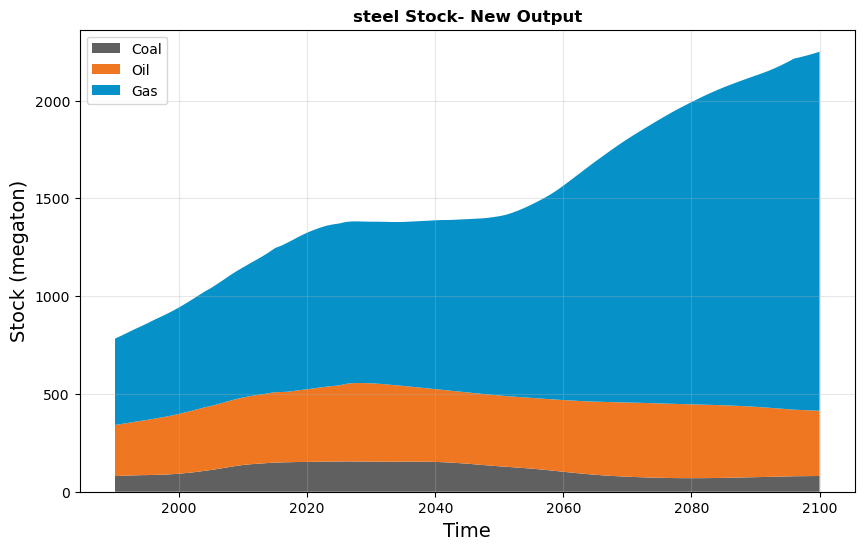

In [28]:
logging.getLogger('matplotlib').setLevel(logging.ERROR)

material = "steel"
unit = "megaton"
firstplotyear = 1990
lastplotyear = 2100
scenario_output = new_output = all_output["SSP2"]

#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = scenario_output.ff_extr["stock_by_cohort_materials"].sel(material=material, Type=gas_extraction_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_pipe = scenario_output.ff_pipe["stock_by_cohort_materials"] .sel(material=material, Type=gas_pipeline_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_proc = scenario_output.ff_proc["stock_by_cohort_materials"].sel(material=material, Type=gas_processing_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_trp = scenario_output.ff_trp["stock_by_cohort_materials"].sel(material=material, Type=gas_transport_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_extr = scenario_output.ff_extr["stock_by_cohort_materials"] .sel(material=material, Type=oil_extraction_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_pipe = scenario_output.ff_pipe["stock_by_cohort_materials"].sel(material=material, Type=oil_pipeline_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_proc = scenario_output.ff_proc["stock_by_cohort_materials"] .sel(material=material, Type=oil_processing_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_trp = scenario_output.ff_trp["stock_by_cohort_materials"] .sel(material=material, Type=oil_transport_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_str = scenario_output.ff_str["stock_by_cohort_materials"] .sel(material=material, Type=oil_storage_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_extr = scenario_output.ff_extr["stock_by_cohort_materials"].sel(material=material, Type=coal_extraction_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_proc = scenario_output.ff_proc["stock_by_cohort_materials"].sel(material=material, Type=coal_processing_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_trp = scenario_output.ff_trp["stock_by_cohort_materials"] .sel(material=material, Type=coal_transport_types, Time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)

gas_total = gas_extr + gas_pipe + gas_trp + gas_proc
coal_total = coal_extr + coal_proc + coal_trp
oil_total = oil_extr + oil_pipe + oil_proc + oil_trp + oil_str
total_overall = gas_total + coal_total + oil_total

fig, ax = plt.subplots(figsize=(10,6))

ax.stackplot(
    gas_total.Time.values,
    coal_total.values,   # bottom
    oil_total.values,    # middle
    gas_total.values,    # top
    labels=["Coal", "Oil", "Gas"],
    colors=["#606060", "#F07721", "#0692C9"]
)

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel(f"Stock ({unit})", fontsize=14)
ax.set_title(f"{material} Stock- New Output", fontweight="bold")

ax.legend(loc="upper left")
ax.grid(alpha=0.3)

print(total_overall.sel(Time=[2019, 2050]).to_series())




### Fill in the material for inflow/outflow

time
2019    38.117525
2050    33.305977
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


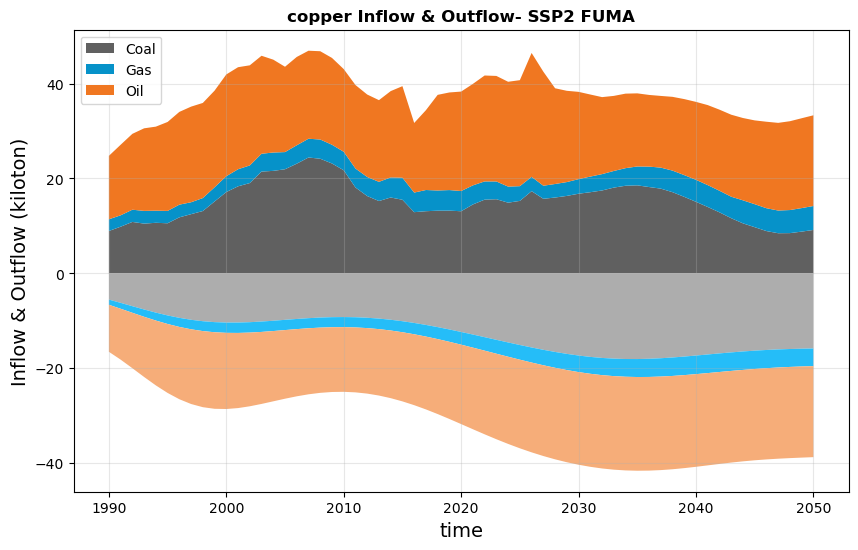

In [34]:
# Test idea for final figures 

material = "copper"
unit = "kiloton"
firstplotyear = 1990
lastplotyear = 2050
scenario_output = new_output = all_output["SSP2"]


#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = scenario_output.ff_extr["inflow_materials"].to_array().sel(material=material, Type=gas_extraction_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_pipe = scenario_output.ff_pipe["inflow_materials"].to_array().sel(material=material, Type=gas_pipeline_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_storage = scenario_output.ff_str["inflow_materials"].to_array().sel(material=material,Type=oil_storage_types,time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_proc = scenario_output.ff_proc["inflow_materials"].to_array().sel(material=material, Type=gas_processing_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_trp = scenario_output.ff_trp["inflow_materials"].to_array().sel(material=material, Type=gas_transport_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_extr = scenario_output.ff_extr["inflow_materials"] .to_array().sel(material=material, Type=oil_extraction_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_pipe = scenario_output.ff_pipe["inflow_materials"].to_array().sel(material=material, Type=oil_pipeline_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_proc = scenario_output.ff_proc["inflow_materials"].to_array().sel(material=material, Type=oil_processing_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_trp = scenario_output.ff_trp["inflow_materials"] .to_array().sel(material=material, Type=oil_transport_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_extr = scenario_output.ff_extr["inflow_materials"].to_array().sel(material=material, Type=coal_extraction_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_proc = scenario_output.ff_proc["inflow_materials"].to_array().sel(material=material, Type=coal_processing_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_trp = scenario_output.ff_trp["inflow_materials"] .to_array().sel(material=material, Type=coal_transport_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)


gas_total = gas_extr + gas_pipe + gas_trp + gas_proc
coal_total = coal_extr + coal_proc + coal_trp
oil_total = oil_extr + oil_pipe + oil_proc + oil_trp + oil_storage
total_overall = gas_total + coal_total + oil_total

#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr_out = scenario_output.ff_extr["outflow_by_cohort_materials"].to_array().sel(material=material, Type=gas_extraction_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_pipe_out = scenario_output.ff_pipe["outflow_by_cohort_materials"].to_array().sel(material=material, Type=gas_pipeline_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_storage_out = scenario_output.ff_str["outflow_by_cohort_materials"].to_array().sel(material=material,Type=oil_storage_types,time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_proc_out = scenario_output.ff_proc["outflow_by_cohort_materials"].to_array().sel(material=material, Type=gas_processing_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
gas_trp_out = scenario_output.ff_trp["outflow_by_cohort_materials"].to_array().sel(material=material, Type=gas_transport_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_extr_out = scenario_output.ff_extr["outflow_by_cohort_materials"] .to_array().sel(material=material, Type=oil_extraction_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_pipe_out = scenario_output.ff_pipe["outflow_by_cohort_materials"].to_array().sel(material=material, Type=oil_pipeline_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_proc_out = scenario_output.ff_proc["outflow_by_cohort_materials"].to_array().sel(material=material, Type=oil_processing_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
oil_trp_out = scenario_output.ff_trp["outflow_by_cohort_materials"] .to_array().sel(material=material, Type=oil_transport_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_extr_out = scenario_output.ff_extr["outflow_by_cohort_materials"].to_array().sel(material=material, Type=coal_extraction_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_proc_out = scenario_output.ff_proc["outflow_by_cohort_materials"].to_array().sel(material=material, Type=coal_processing_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)
coal_trp_out = scenario_output.ff_trp["outflow_by_cohort_materials"] .to_array().sel(material=material, Type=coal_transport_types, time=slice(firstplotyear, lastplotyear)).sum(dim="Type").sum(dim="Region").pint.to(unit)

# Sum of all
gas_total_out = gas_extr_out + gas_pipe_out + gas_proc_out + gas_trp_out
coal_total_out = coal_extr_out + coal_proc_out + coal_trp_out
oil_total_out = oil_extr_out + oil_pipe_out + oil_proc_out+ oil_trp_out + oil_storage_out
total_overall_out = gas_total_out + coal_total_out + oil_total_out


fig, ax = plt.subplots(figsize=(10,6))

ax.stackplot(
    gas_total.time.values,
    coal_total.values,   # bottom
    gas_total.values, 
    oil_total.values,    # middle
    labels=["Coal", "Gas", "Oil"],
    colors=["#606060","#0692C9", "#F07721"]
)

ax.stackplot(
    gas_total_out.time.values,
    -coal_total_out.values, 
    -gas_total_out.values,  # bottom
    -oil_total_out.values,    # middle
    # labels=["Coal", "Oil", "Gas"],
    colors=["#ADADAD",  "#25BDF8", "#F6AD79"]
)

ax.set_xlabel("time", fontsize=14)
ax.set_ylabel(f"Inflow & Outflow ({unit})", fontsize=14)
ax.set_title(f"{material} Inflow & Outflow- SSP2 FUMA", fontweight="bold")

ax.legend(loc="upper left")
ax.grid(alpha=0.3)


# print(total_overall.sel(Time=[2019, 2050]).to_series())

# print(gas_processing.sel(Time=[2019, 2050]).to_series())

print(total_overall.sel(time=[2019, 2050]).to_series())

#line charts comparing total stock, inflow, outflow for each material
# Line chart comparing scenarios for total stock, inflow, outflow for each material/each fuel type 
# run and create totals for each materials and then make a figure with those totals compared?


